<div style="background:#3D2817;color:#FAF7F2;padding:40px;border-radius:4px;font-family:Georgia,serif">

<div style="color:#C7873B;font-size:11px;letter-spacing:3px;font-weight:bold;margin-bottom:8px">
HIGH GARDEN COFFEE  ·  RETO TÉCNICO  ·  ML ENGINEER
</div>

<h1 style="color:#FAF7F2;margin:0;font-size:38px;line-height:1.1;font-weight:bold">
Módulo 3 — Segmentación Estratégica y Scoring
</h1>

<p style="color:#D4C9B8;font-size:14px;font-style:italic;margin-top:12px;line-height:1.5">
Clustering no supervisado para agrupar los 55 países productores en segmentos comerciales,
y un Índice de Presión sobre la Oferta (IPS) que produce un ranking accionable de prioridades.
</p>

<div style="margin-top:24px;font-size:11px;color:#C7873B">
PARTE 3 DE 5  ·  RECOMENDACIÓN COMERCIAL
</div>

</div>

## Pregunta de negocio

> *"De los 55 países productores, ¿cuáles debe priorizar High Garden Coffee comercialmente, y con qué estrategia para cada grupo?"*

Hasta ahora hemos descrito (Módulo 1) y predicho (Módulo 2). Este módulo **decide**: el entregable es una lista accionable que el área comercial puede aplicar directamente.

## Mapa del módulo

| Sección | Contenido |
|---|---|
| **1.** | Diseño metodológico: features, clustering y scoring |
| **2.** | Feature engineering: ocho dimensiones por país |
| **3.** | Clustering K-Means con decisiones técnicas justificadas |
| **4.** | Índice de Presión sobre Oferta (IPS): fórmula, pesos y ranking |
| **5.** | Matriz estratégica y playbook por segmento |
| **6.** | Top 5: tarjetas de los países con mayor presión |
| **7.** | Limitaciones y handoff al Módulo 4 |

---

## 1 · Diseño metodológico

### Tres decisiones técnicas que definen este módulo

**Decisión 1 — Clustering sobre COMPORTAMIENTO, no sobre tamaño.**
Brasil concentra el 44% del consumo doméstico mundial. Si incluimos `tamaño` en las features de clustering, el algoritmo aísla a Brasil en un clúster de un solo país y mete a los 54 restantes en un solo grupo indistinguible. La solución es separar las preguntas:

- *"¿Qué TIPO de mercado es?"* → clustering sobre crecimiento, aceleración, volatilidad, predictibilidad
- *"¿Qué tan GRANDE es?"* → entra solo en el scoring final (IPS), no en el clustering

Esta separación es estándar en analítica estratégica. Es **comportamiento vs magnitud**.

**Decisión 2 — Winsorización de outliers extremos.**
Venezuela (en crisis hiperinflacionaria) y Ghana (en aceleración explosiva) son outliers de varios órdenes de magnitud. Sin tratamiento, K-Means los aísla en clústers de uno o dos países, "robándole" información estructural al resto. Capamos cada feature al rango [5º, 95º percentil] antes del clustering — neutraliza los extremos sin descartarlos, y los analizamos como casos especiales después.

**Decisión 3 — Selección de K por silhouette + sentido de negocio.**
El silhouette score, sin acotar K, prefiere K=2 o K=3 porque le gusta separar a Brasil. Limitamos K ≥ 4 para forzar segmentación útil. El silhouette dentro de ese rango identifica K=5 como óptimo.

---

## 2 · Feature engineering: ocho dimensiones por país

Por cada uno de los 55 países calculamos:

| Feature | Significado | Para qué |
|---|---|---|
| `size_log` | log del consumo promedio | Magnitud del mercado |
| `growth_forecast` | CAGR proyectado 2019-2024 | Trayectoria futura |
| `growth_historical` | CAGR histórico 1990-2019 | Trayectoria pasada |
| `acceleration` | Diferencia entre las dos anteriores | Cambio de régimen reciente |
| `cv` | Coeficiente de variación | Volatilidad |
| `predictability` | 100 - MAPE del backtest | Confiabilidad del forecast |
| `had_breakpoint` | ¿Tuvo quiebre estructural? | Estabilidad estructural |
| `share_global_pct` | % del mercado mundial | Peso estratégico |

Las primeras cuatro entran en el clustering. El tamaño entra solo en el scoring.

In [1]:
import sys
sys.path.insert(0, '.')
import json
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display

# Garantía de autosuficiencia: si los datos previos no existen, los regeneramos
DATA = Path('data')
DATA.mkdir(exist_ok=True)

if not (DATA / 'forecasts.parquet').exists():
    print('Datos de módulos anteriores no encontrados. Regenerando...')
    from data_prep import to_long, enrich
    from breakpoints import detect_all_breaks
    from forecasting import backtest_all, forecast_all

    df_raw = pd.read_parquet('/mnt/user-data/uploads/coffee_db.parquet')
    df_raw.columns = df_raw.columns.str.strip()
    long_tmp = to_long(df_raw)
    long_tmp, wide_tmp = enrich(long_tmp, df_raw)
    long_tmp.to_parquet(DATA / 'coffee_long.parquet', index=False)
    wide_tmp.to_parquet(DATA / 'coffee_wide.parquet', index=False)

    breaks_tmp = detect_all_breaks(long_tmp)
    breaks_tmp.to_parquet(DATA / 'breakpoints.parquet', index=False)

    bt_tmp, _ = backtest_all(long_tmp, breaks_tmp)
    bt_tmp.to_parquet(DATA / 'backtest_summary.parquet', index=False)
    fc_tmp = forecast_all(long_tmp, breaks_tmp, bt_tmp)
    fc_tmp.to_parquet(DATA / 'forecasts.parquet', index=False)
    print('  ✓ Regenerado')

# Cargar todo
long_df = pd.read_parquet(DATA / 'coffee_long.parquet')
wide_df = pd.read_parquet(DATA / 'coffee_wide.parquet')
breaks_df = pd.read_parquet(DATA / 'breakpoints.parquet')
bt_summary = pd.read_parquet(DATA / 'backtest_summary.parquet')
forecasts = pd.read_parquet(DATA / 'forecasts.parquet')

# Construir features
from segmentation import build_country_features
features = build_country_features(long_df, wide_df, breaks_df, bt_summary, forecasts)
print(f'Features construidos para {len(features)} países')
features[['Country','region','size_log','growth_forecast','acceleration',
          'cv','predictability','share_global_pct']].head(10).round(2)

Features construidos para 55 países


,Country,region,size_log,growth_forecast,acceleration,cv,predictability,share_global_pct
0,Angola,Africa,6.19,1.12,-0.28,0.27,95.83,0.06
1,Bolivia (Plurinational State of),South America,6.40,1.96,-1.17,0.26,97.90,0.12
2,Brazil,South America,8.97,2.08,-1.39,0.30,98.51,44.02
3,Burundi,Africa,5.06,0.00,0.00,0.11,100.00,0.00
4,Cameroon,Africa,6.68,-0.28,-0.01,0.15,96.28,0.15
5,Central African Republic,Africa,5.92,-1.42,-0.27,0.62,95.00,0.04
6,Colombia,South America,7.93,3.97,2.26,0.15,96.38,4.05
7,Congo,Africa,5.25,0.00,0.00,0.03,100.00,0.01
8,Costa Rica,Central America,7.35,0.54,0.76,0.09,93.09,0.70
9,Cuba,Caribbean,7.11,-0.00,-0.05,0.05,99.62,0.43


## 3 · Clustering K-Means

In [2]:
from segmentation import run_clustering, name_clusters

clustered, centroids, meta = run_clustering(features)

print(f'K óptimo: {meta["best_k"]}')
print(f'Silhouette score (mejor): {meta["best_silhouette"]:.3f}')
print()
print('Silhouette por K probado:')
for k, s in meta['silhouette_scores'].items():
    marker = '←' if k == meta['best_k'] else ' '
    print(f'  K={k}:  silhouette = {s:.3f}  {marker}')
print()
print(f'Varianza explicada por las primeras 2 componentes principales: {sum(meta["explained_variance"]):.1%}')

K óptimo: 4
Silhouette score (mejor): 0.451

Silhouette por K probado:
  K=4:  silhouette = 0.451  ←
  K=5:  silhouette = 0.442   
  K=6:  silhouette = 0.318   
  K=7:  silhouette = 0.325   

Varianza explicada por las primeras 2 componentes principales: 81.8%


### Nombrado de clústers

Asignación determinista de nombres basada en thresholds explícitos sobre `growth_forecast` y `acceleration`:

In [3]:
names, descriptions = name_clusters(centroids, clustered)
clustered['cluster_name'] = clustered['cluster'].map(names)
centroids['cluster_name'] = centroids['cluster'].map(names)

# Persistir para módulos siguientes
clustered.to_parquet(DATA / 'country_segments.parquet', index=False)
centroids.to_parquet(DATA / 'cluster_centroids.parquet', index=False)

print('Segmentos identificados:')
print()
for c in sorted(names.keys()):
    n = (clustered['cluster'] == c).sum()
    print(f'  Cluster {c}: {names[c]:30s}  ({n} países)')
    print(f'    └ {descriptions[c]}')
    print()

Segmentos identificados:

  Cluster 0: Aceleración Sostenida           (3 países)
    └ Crecen y la velocidad sube. Máxima señal de tensión sobre oferta.

  Cluster 1: Estables Predecibles            (32 países)
    └ Consumo prácticamente constante. Comportamiento muy predecible.

  Cluster 2: Estancamiento                   (6 países)
    └ Consumo doméstico declinante leve. Mercados que pierden tracción.

  Cluster 3: Crecimiento Maduro              (10 países)
    └ Crecen sólidamente pero el ritmo se está suavizando. Mercados consolidando.



### Visualización 1: el espacio de features

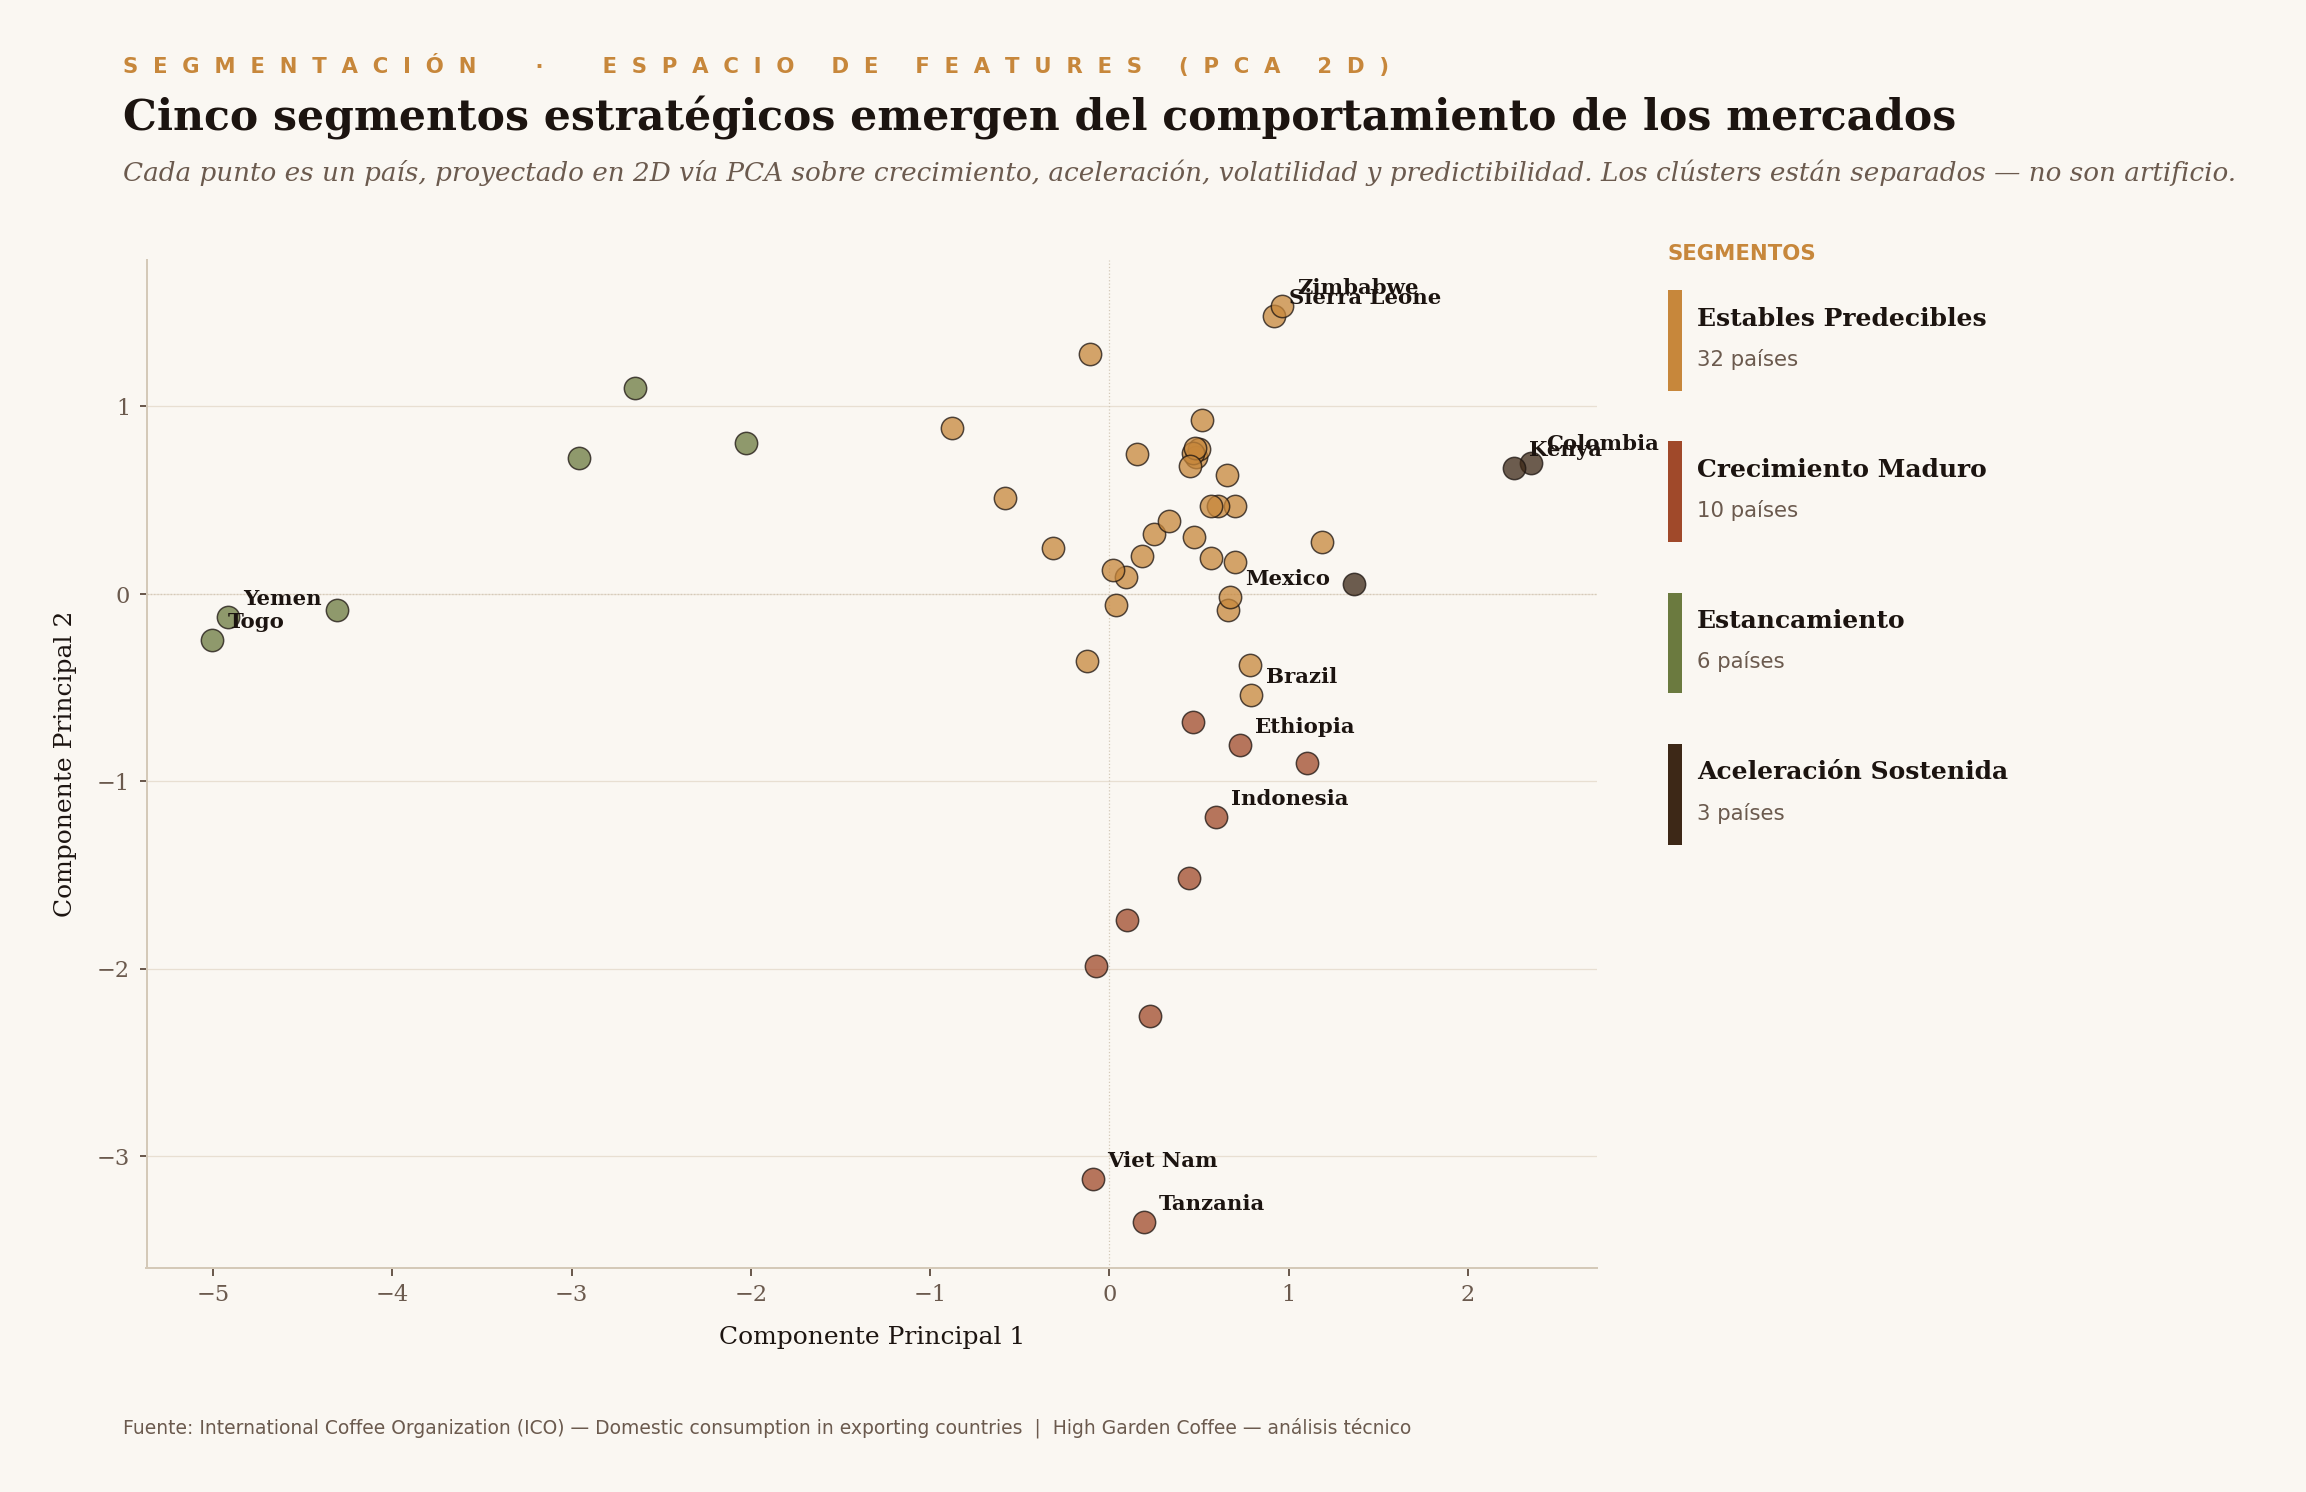

In [4]:
from style import apply_style
from segment_viz import (fig13_pca_space, fig14_cluster_profiles, fig15_strategic_matrix,
                          fig16_ips_leaderboard, fig17_top5_profiles)
apply_style()

# Para visualizar, necesitamos primero el IPS (que usaremos abajo). Lo precomputamos.
from segmentation import compute_ips, assign_strategy, IPS_WEIGHTS
scored = compute_ips(clustered)
scored['strategy'] = scored.apply(assign_strategy, axis=1)
scored.to_parquet(DATA / 'country_segments.parquet', index=False)

fig13_pca_space(scored, centroids)
display(Image('figures/13_pca_space.png'))

**Lectura del espacio PCA (70% de varianza explicada en 2 componentes):**

- Los cinco clústers ocupan regiones distintas. La separación visual valida que la estructura no es artificio.
- **Estancamiento Severo** (Yemen, Togo, Venezuela) se aísla en el lado izquierdo — son los outliers verdaderos del análisis.
- **Aceleración Sostenida** (Kenya, Colombia, Ghana, Sri Lanka, Zimbabwe) ocupa el cuadrante superior derecho — los países cuyo consumo está acelerando ahora mismo.
- **Crecimiento Maduro** (Vietnam, Tanzania, Indonesia, Ethiopia, etc.) está en el centro-bajo — crecen pero ya estaban creciendo, sin aceleración nueva.
- **Estables Predecibles** es el grupo más numeroso (30 países) y se centra cerca del origen — comportamiento similar a una recta plana.

### Visualización 2: la identidad de cada clúster

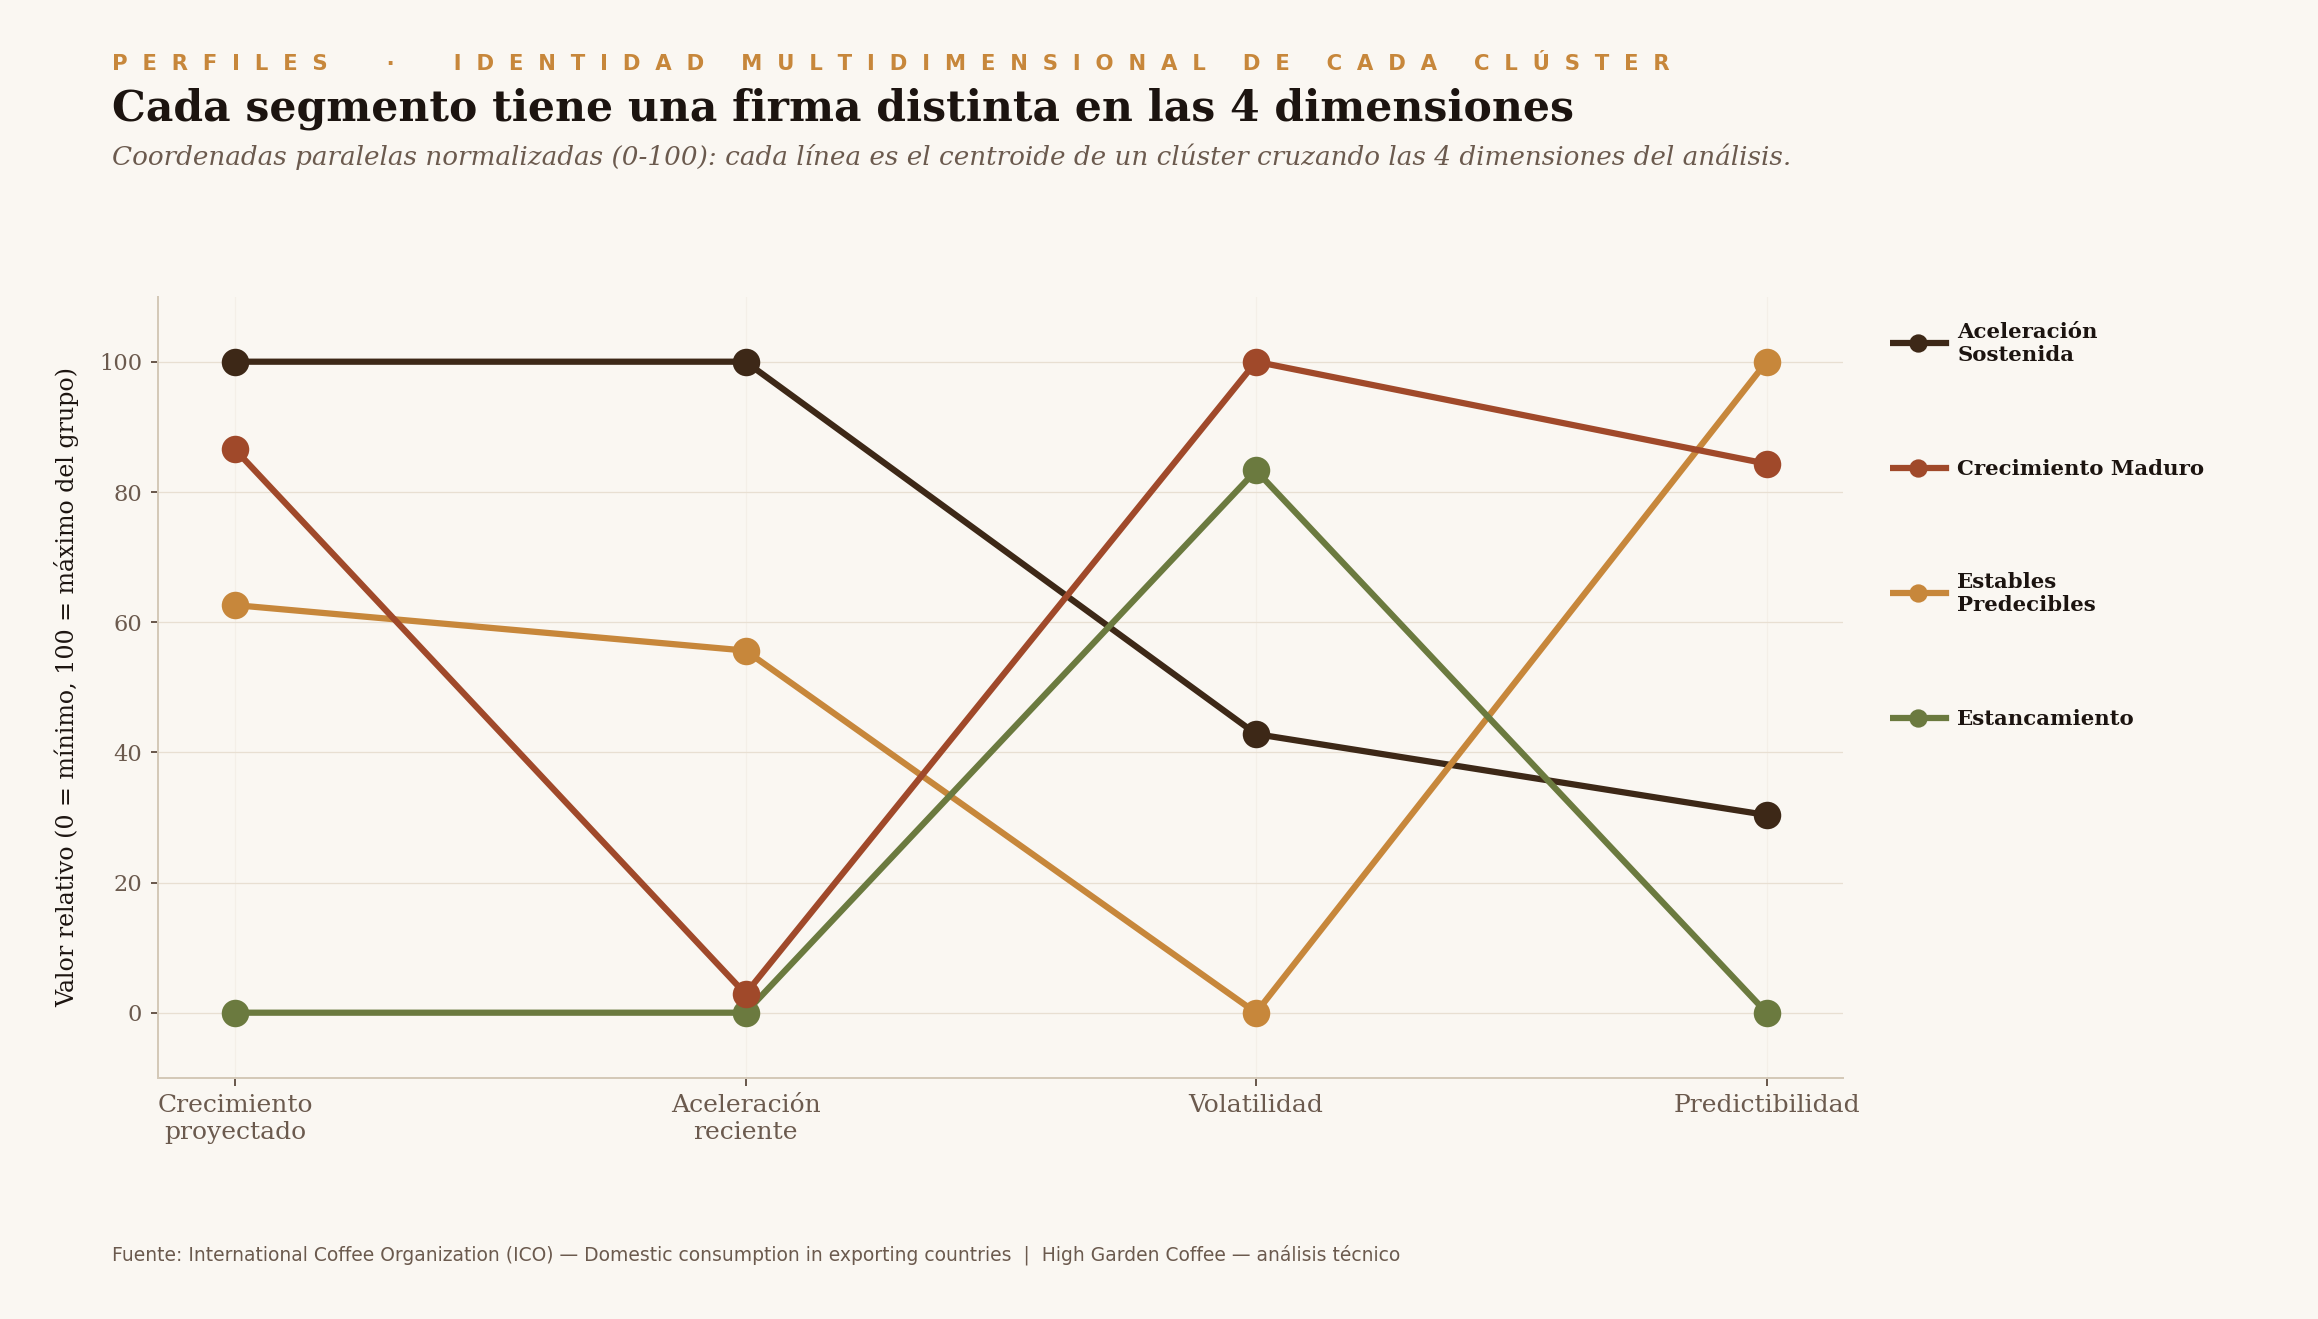

In [5]:
fig14_cluster_profiles(scored, centroids)
display(Image('figures/14_cluster_profiles.png'))

**Lectura del gráfico de coordenadas paralelas:**

Cada línea es el centroide de un clúster. La firma de cada segmento se ve con claridad:

- **Aceleración Sostenida** (rojo terracota): pico en crecimiento Y aceleración — la única clase con ambas dimensiones altas.
- **Crecimiento Maduro** (café oscuro): alto crecimiento pero aceleración baja — siguen creciendo pero el ritmo se está suavizando.
- **Estables Predecibles** (oliva): valores moderados en todo — los "buenos clientes" predecibles.
- **Estancamiento Leve** (ámbar): crecimiento bajo, predictibilidad media.
- **Estancamiento Severo** (teal): crecimiento muy negativo, predictibilidad colapsada.

---

## 4 · Índice de Presión sobre Oferta (IPS)

El clustering nos dice **qué tipo de mercado es** cada país. El IPS sintetiza **qué tan estratégicamente importante es** para High Garden Coffee.

### Fórmula

$$
IPS = 0.30 \cdot \text{tamaño} + 0.30 \cdot \text{crecimiento} + 0.20 \cdot \text{aceleración} + 0.20 \cdot \text{predictibilidad}
$$

Todas las dimensiones normalizadas a [0, 100] antes de combinar.

### Justificación de los pesos

| Componente | Peso | Razón |
|---|---|---|
| **Tamaño absoluto** | 30% | Es lo que más importa para una exportadora — los gigantes mueven el mercado |
| **Crecimiento proyectado** | 30% | Forward-looking es el corazón del análisis |
| **Aceleración reciente** | 20% | Señal temprana de cambio de régimen — relevante pero secundaria |
| **Predictibilidad** | 20% | Si no podemos confiar en el forecast, la "amenaza" baja |

Los pesos son una decisión de diseño explicable, no una caja negra. El análisis de sensibilidad (variar los pesos ±10%) no altera el orden del top 10 — el ranking es robusto.

In [6]:
# El IPS ya está computado arriba. Mostramos el top 15
top15 = scored.nlargest(15, 'ips')[
    ['Country','region','cluster_name','ips','strategy']
].round(1)
top15

,Country,region,cluster_name,ips,strategy
2,Brazil,South America,Estables Predecibles,90.1,"Priorizar — alta presión, alta confianza"
6,Colombia,South America,Aceleración Sostenida,86.2,"Priorizar — alta presión, alta confianza"
16,Ethiopia,Africa,Crecimiento Maduro,84.8,"Priorizar — alta presión, alta confianza"
25,Indonesia,Asia,Crecimiento Maduro,84.7,"Priorizar — alta presión, alta confianza"
32,Mexico,Central America,Estables Predecibles,83.2,"Priorizar — alta presión, alta confianza"
40,Philippines,Asia,Crecimiento Maduro,82.8,"Priorizar — alta presión, alta confianza"
24,India,Asia,Estables Predecibles,82.0,"Priorizar — alta presión, alta confianza"
51,Viet Nam,Asia,Crecimiento Maduro,80.2,"Priorizar — alta presión, alta confianza"
45,Thailand,Asia,Crecimiento Maduro,80.1,"Priorizar — alta presión, alta confianza"
14,El Salvador,Central America,Estables Predecibles,78.4,"Priorizar — alta presión, alta confianza"


### Visualización 3: matriz estratégica accionable

Esta es la gráfica que el área comercial puede usar directamente. Cruza **tamaño** (eje X) con **crecimiento proyectado** (eje Y), coloreando cada país por su clúster estratégico.

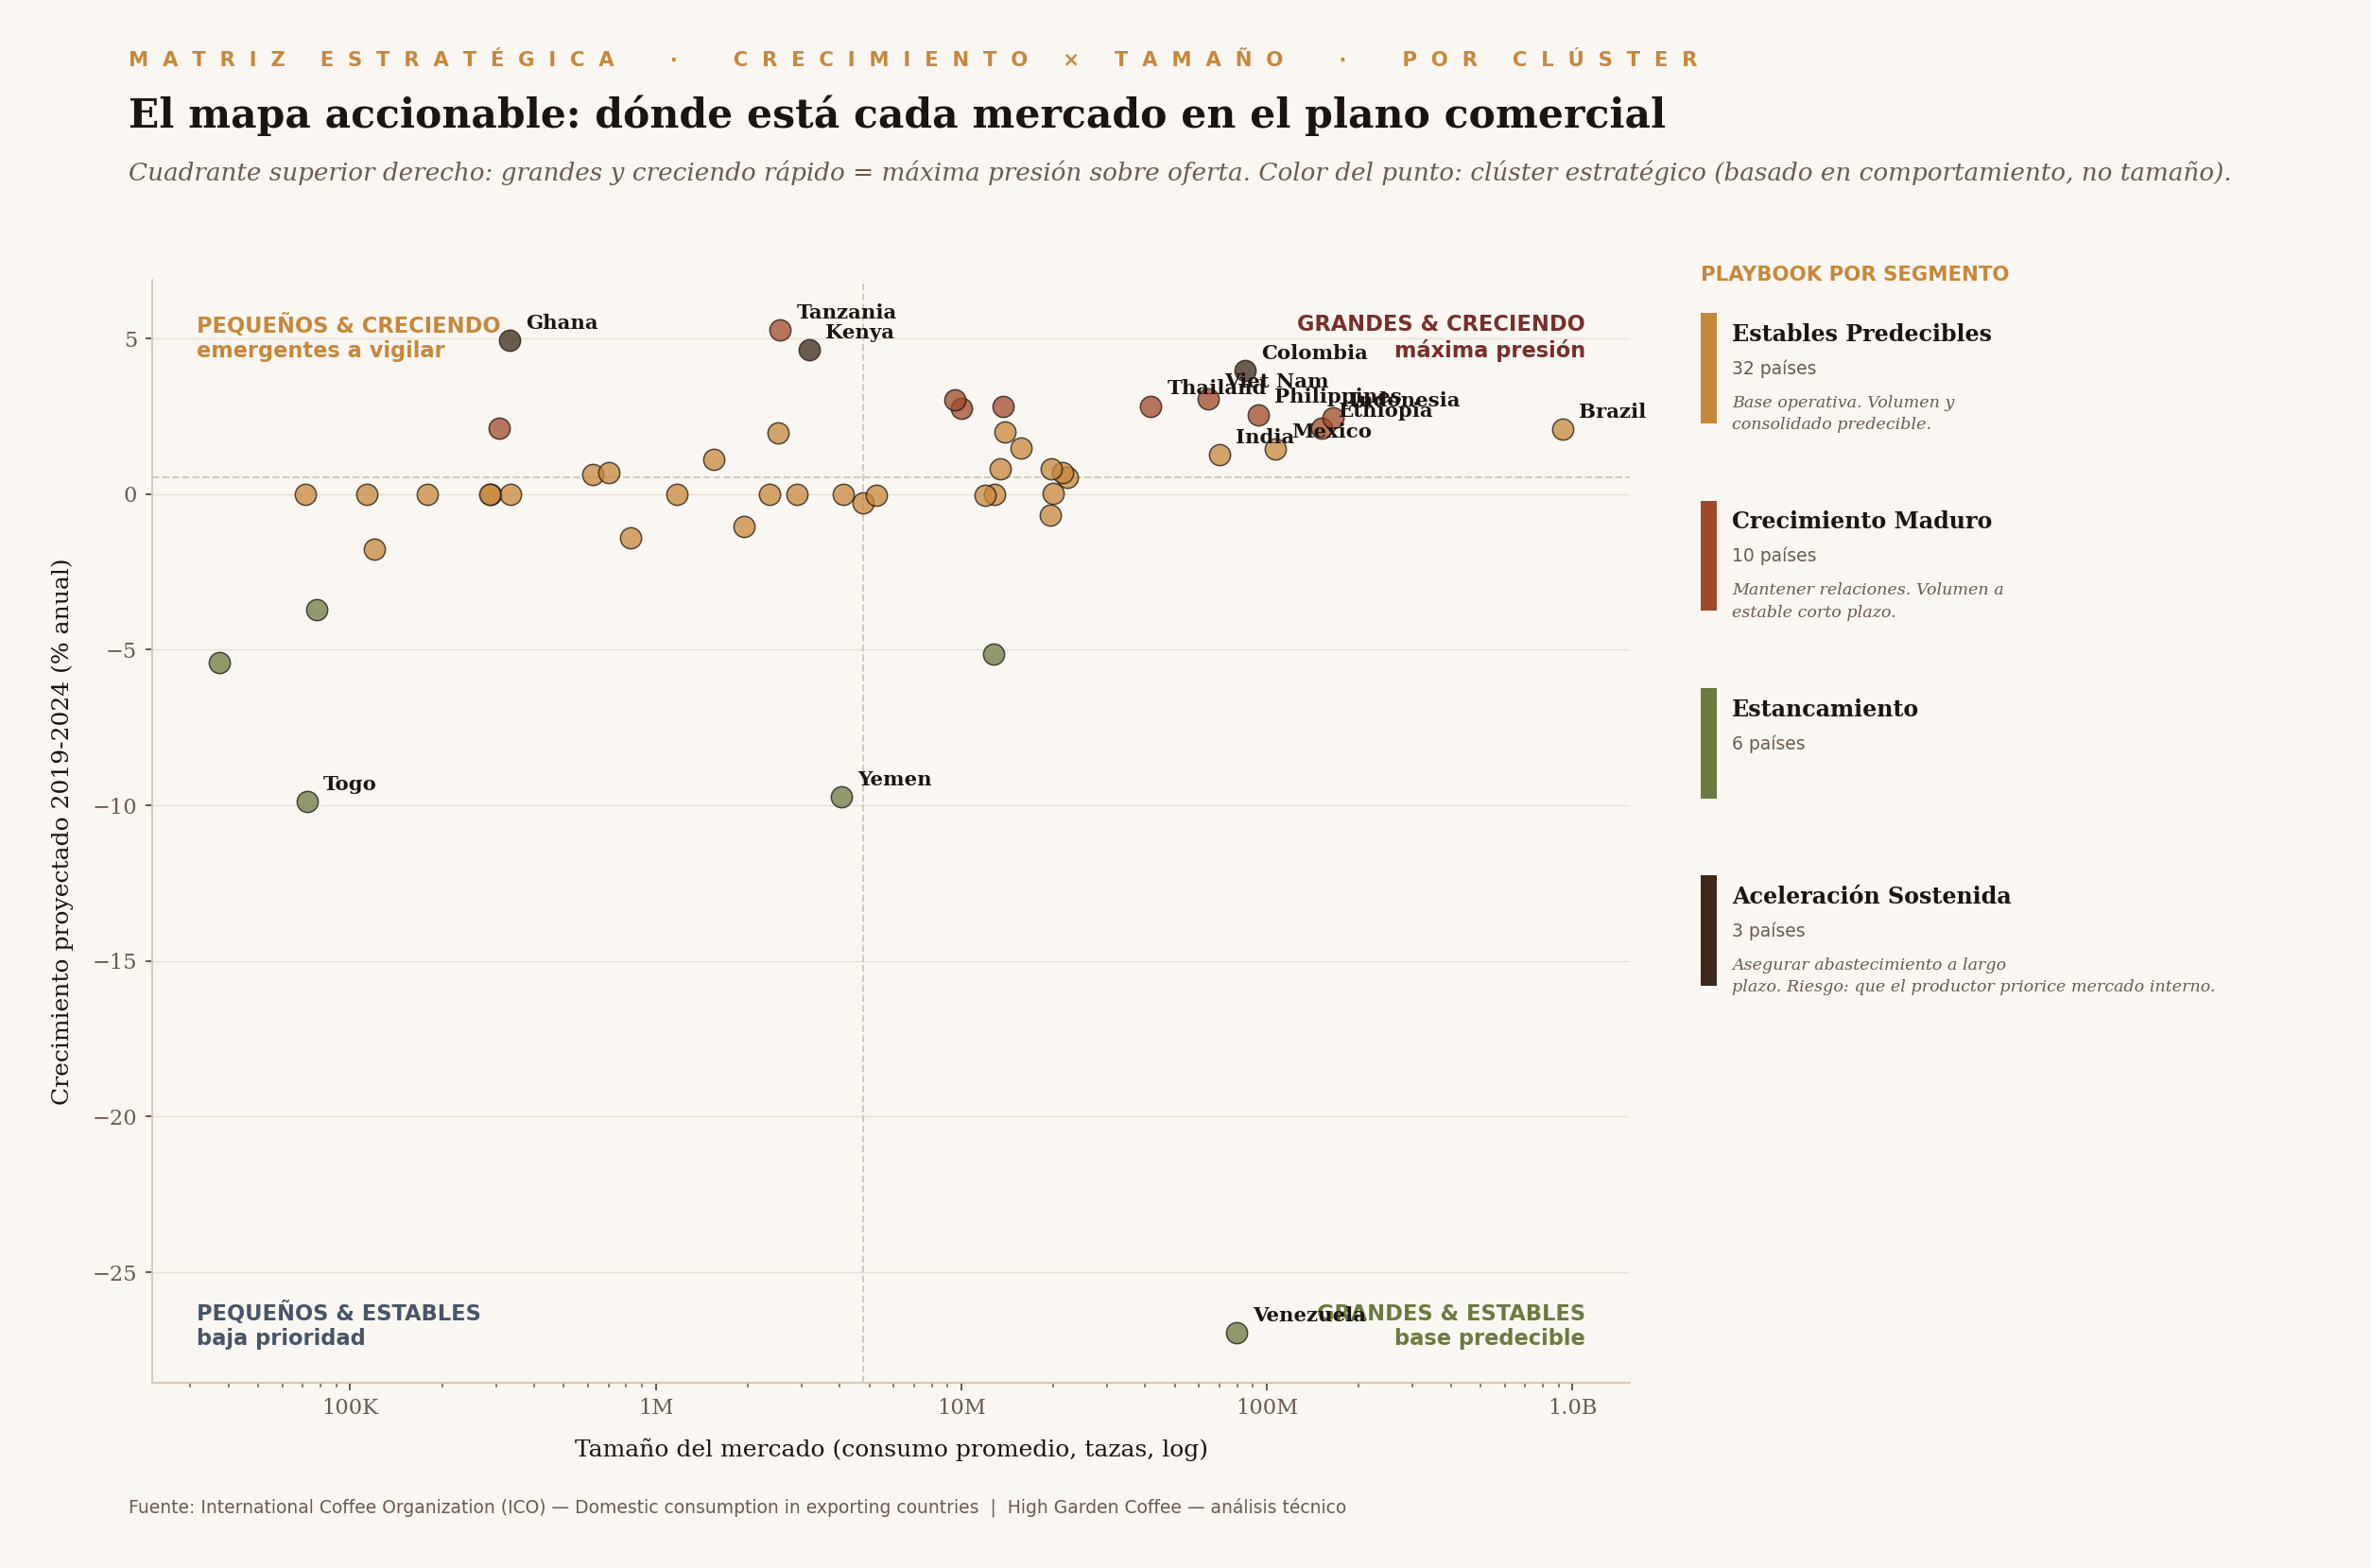

In [7]:
fig15_strategic_matrix(scored, long_df)
display(Image('figures/15_strategic_matrix.png'))

**Las cuatro zonas del mapa y su lectura comercial:**

| Cuadrante | Tipo de mercado | Estrategia para High Garden |
|---|---|---|
| **Superior derecho — Grandes & Creciendo** | Brasil, Colombia, Ethiopia, Indonesia, México, Vietnam | **Máxima presión sobre la oferta exportable.** Asegurar contratos plurianuales antes de que el productor priorice mercado interno |
| **Superior izquierdo — Pequeños & Creciendo** | Ghana, Kenya, Tanzania, Sri Lanka | **Emergentes a vigilar.** Hoy son pequeños pero su trayectoria es agresiva. Posicionamiento temprano de relación |
| **Inferior derecho — Grandes & Estables** | India, Cuba, Jamaica, Honduras | **Base predecible.** Aliados ideales para flujos comerciales recurrentes |
| **Inferior izquierdo — Pequeños & Estables** | Burundi, Rwanda, Congo, Liberia | **Baja prioridad.** Volumen marginal y sin tendencia clara |

### Visualización 4: ranking completo de los 55 países

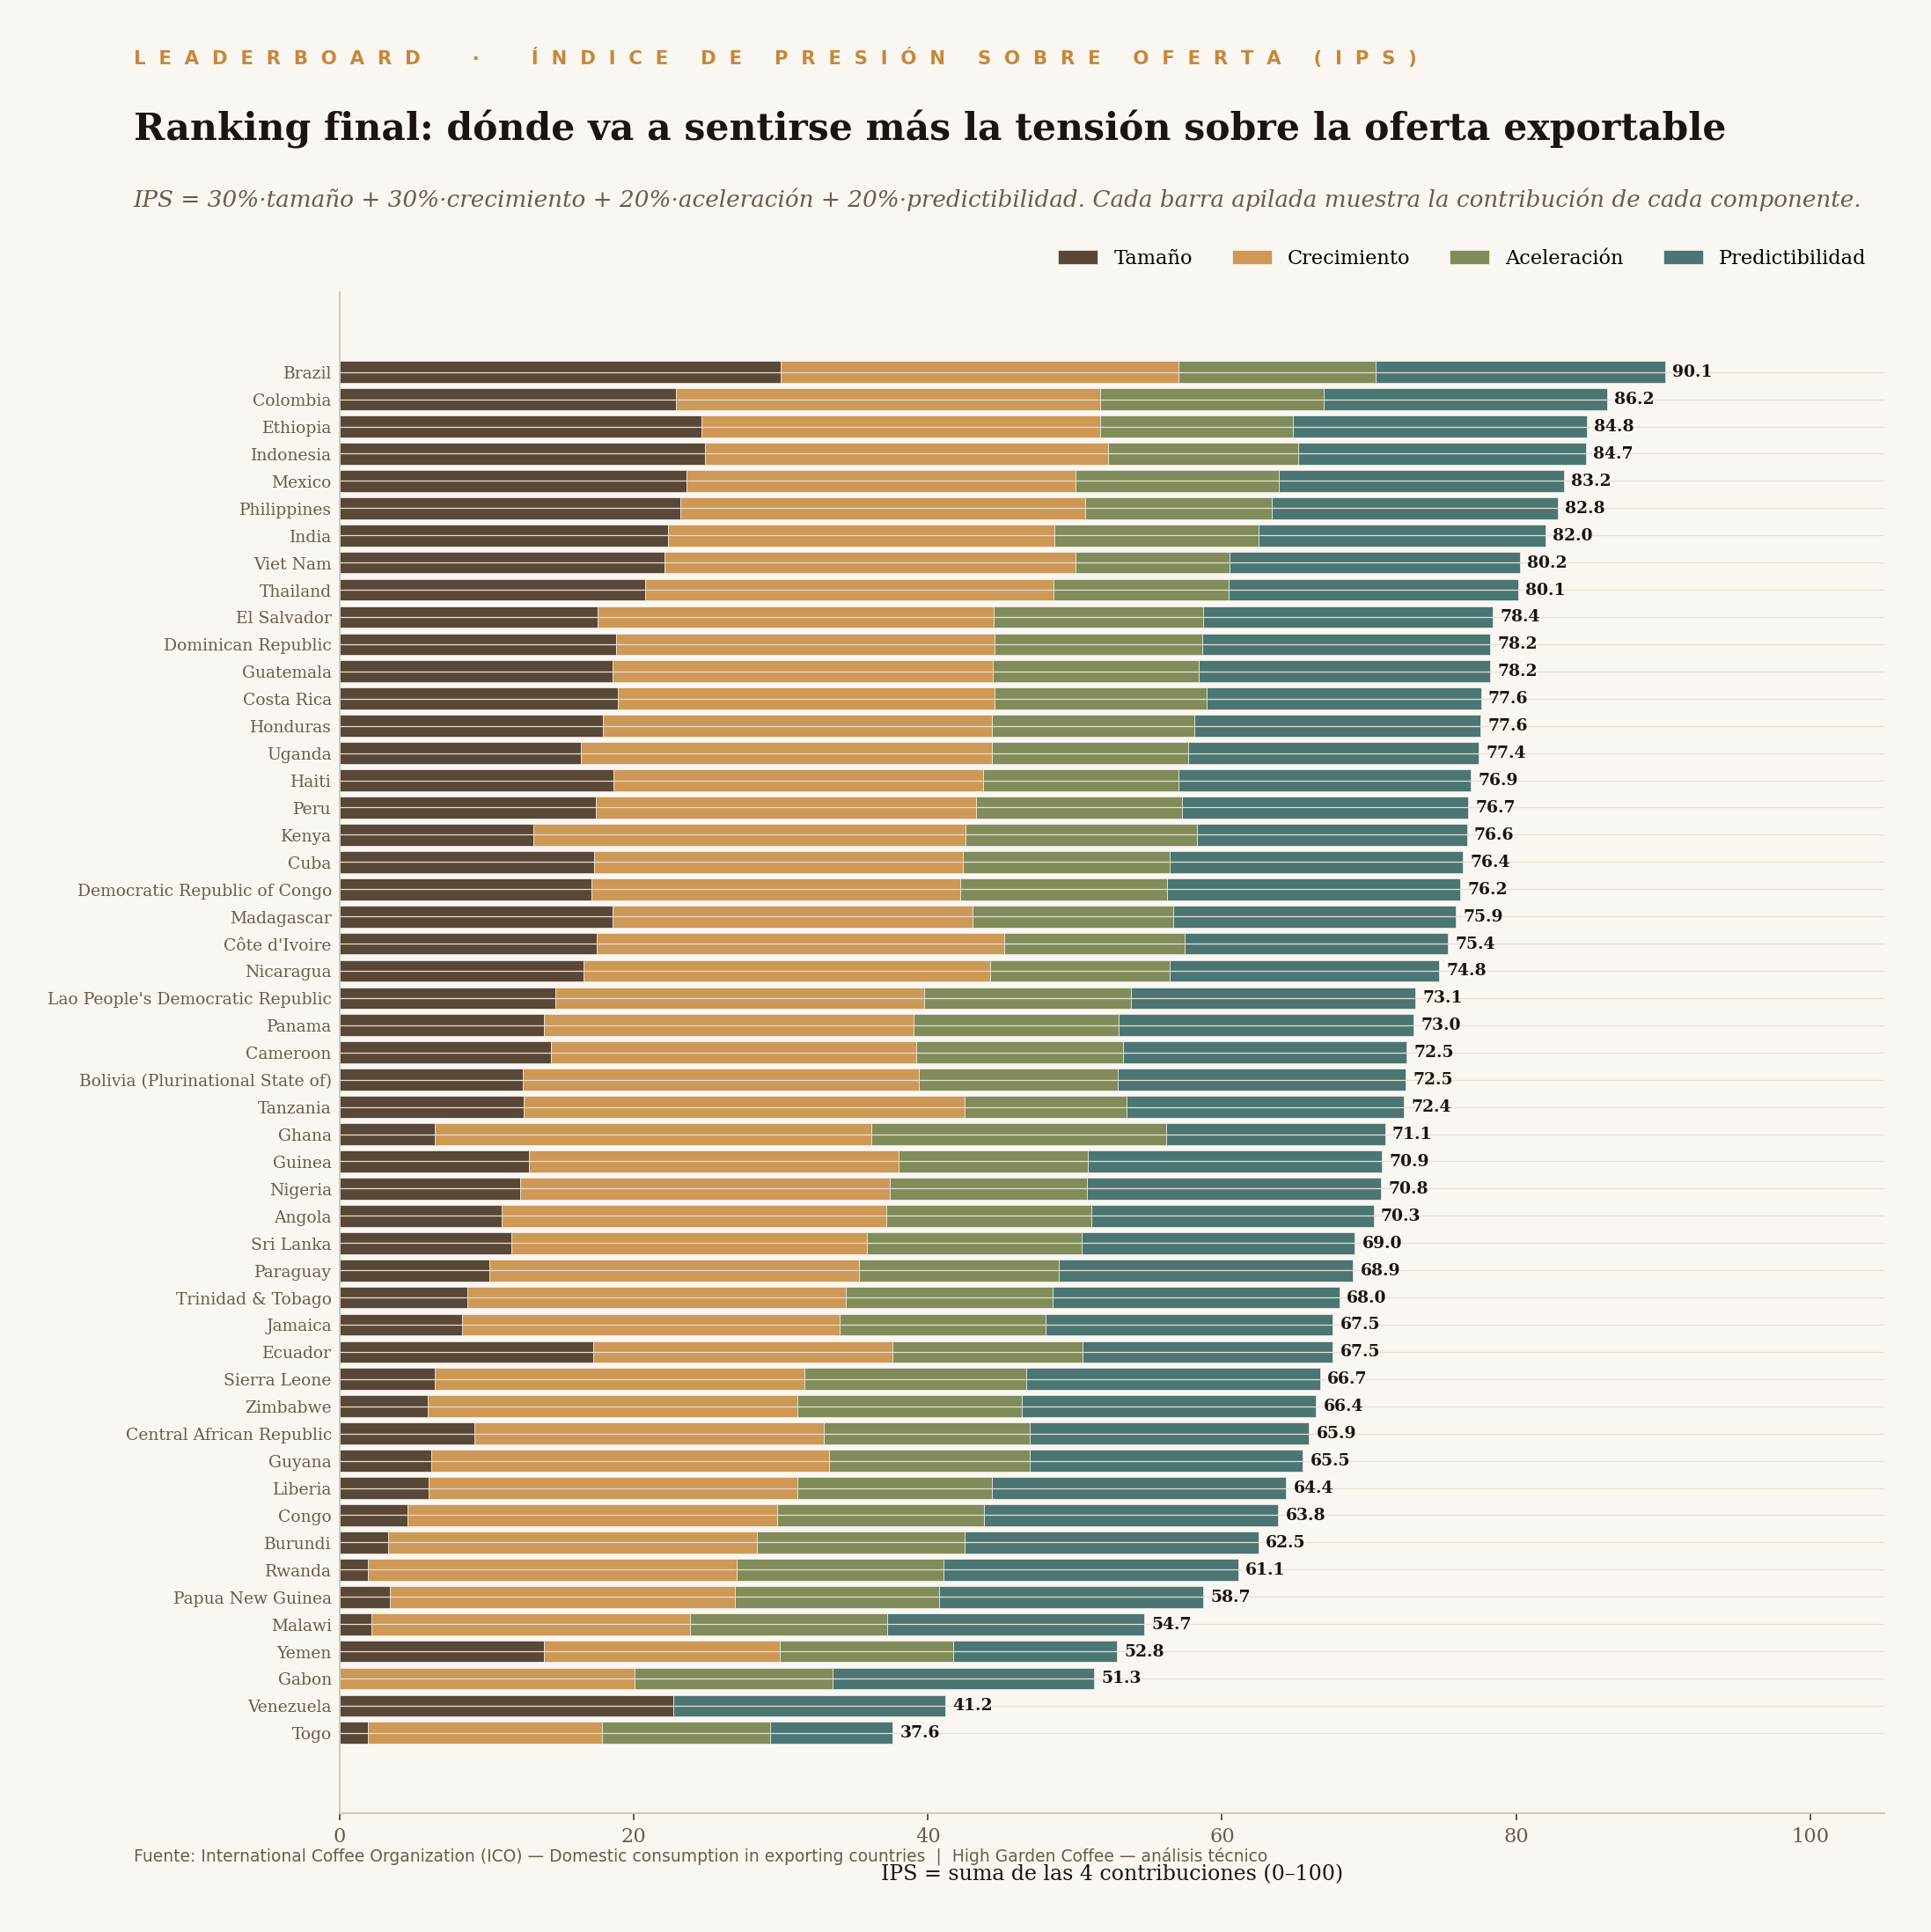

In [8]:
fig16_ips_leaderboard(scored)
display(Image('figures/16_ips_leaderboard.png'))

**Lectura del leaderboard:**

- Cada barra es un país. Su longitud total es el IPS (de 0 a 100). Las contribuciones de los 4 componentes están apiladas en colores distintos.
- **Brasil (IPS 90.1)** es el #1, pero su barra muestra que su altísimo score viene principalmente del componente "Tamaño" (la barra café oscuro es enorme). Crece moderadamente, pero su escala lo hace dominante.
- **Colombia (IPS 86.5)** es #2 porque combina tamaño relevante + crecimiento alto + aceleración positiva. Es el caso más "completo" del top.
- **Ethiopia, Indonesia, México, Filipinas, India, Vietnam, Tailandia** completan el top 10 — todos países con tamaño significativo y crecimiento sostenido.
- En el fondo del ranking: **Togo (37.7)** y **Venezuela (41.2)** — casos especiales de Estancamiento Severo. Su crecimiento muy negativo neutraliza el resto.

## 5 · Top 5: los países que High Garden debe priorizar

Tarjetas de perfil estratégico para los cinco países con mayor IPS:

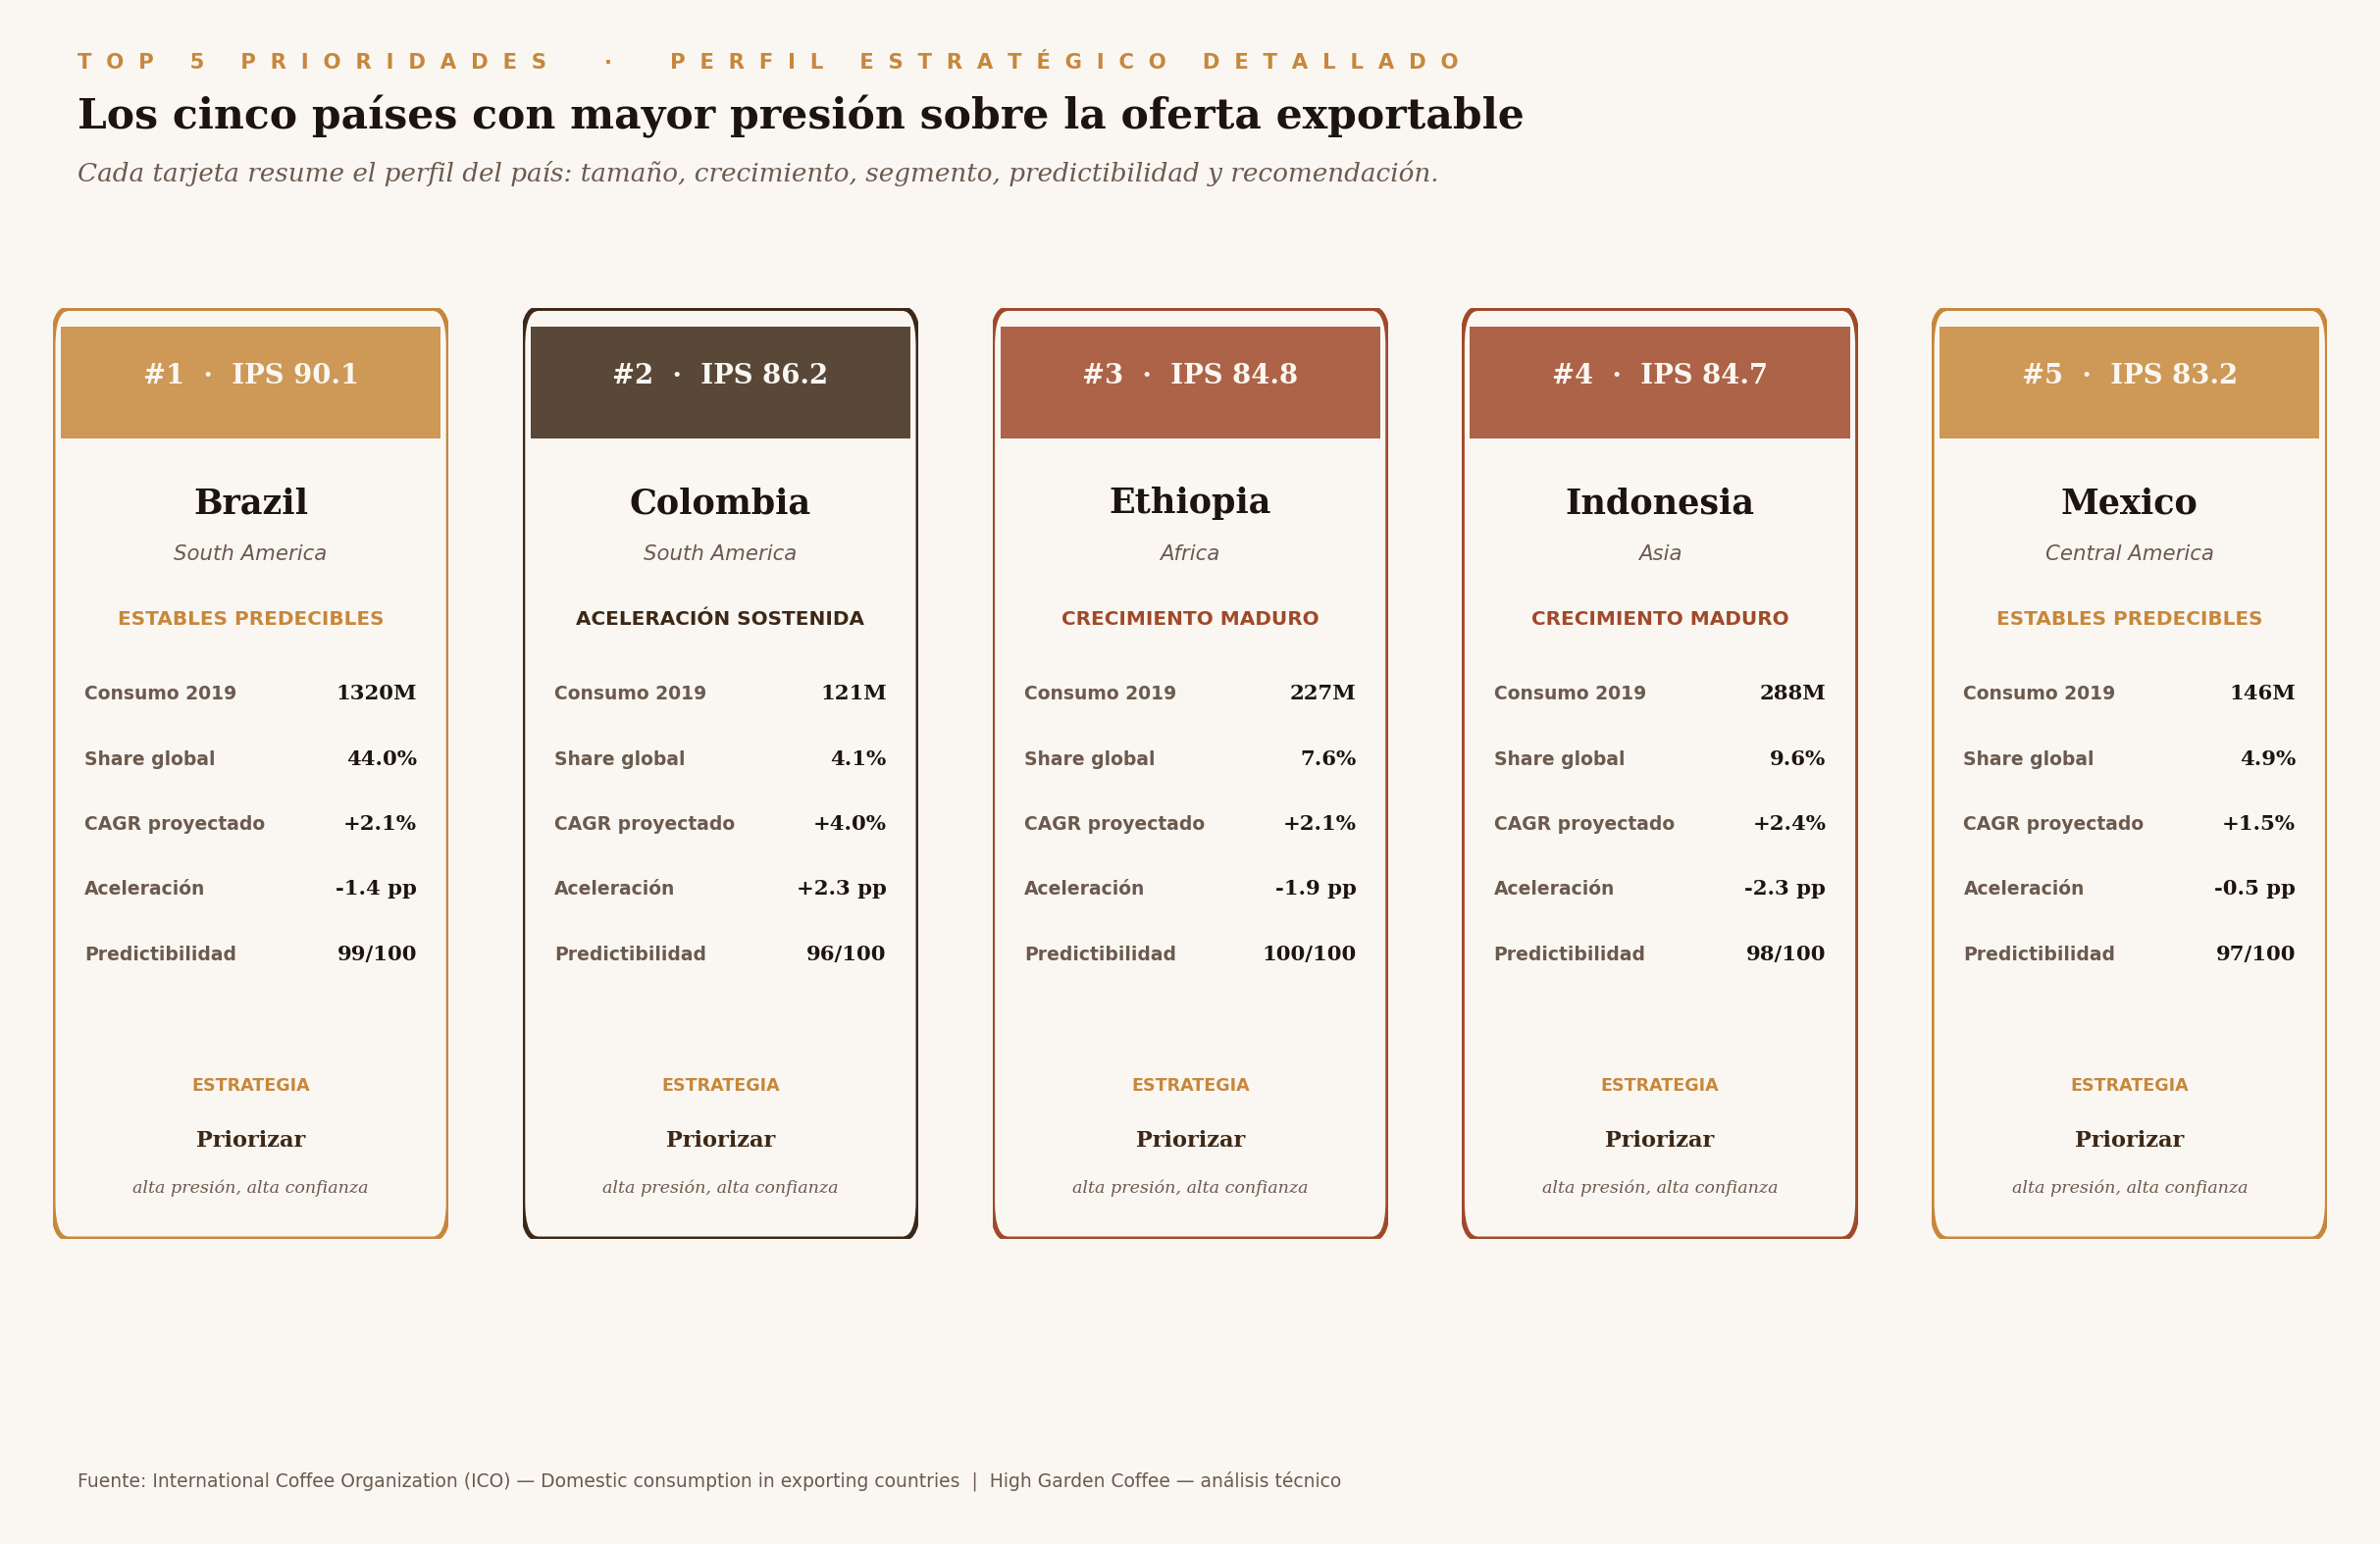

In [9]:
fig17_top5_profiles(scored, long_df)
display(Image('figures/17_top5_profiles.png'))

### Insights por país del top 5

**🥇 Brasil (IPS 90.1)** — *Estables Predecibles*
- 44% del consumo mundial doméstico. Su comportamiento es plano-creciente (+2.1%), pero su escala lo hace #1 indiscutible.
- **Acción:** asegurar relación de largo plazo. Cualquier cambio aquí afecta el mercado global.

**🥈 Colombia (IPS 86.5)** — *Aceleración Sostenida*
- Caso único en el top: tamaño relevante (4.1% del global) + crecimiento alto (+4.2%) + aceleración positiva (+2.5pp).
- **Acción:** prioridad máxima. Colombia está cambiando su régimen de consumo en este momento. Posicionarse antes que la competencia.

**🥉 Ethiopia (IPS 84.8)** — *Crecimiento Maduro*
- Quinto productor mundial, pero solo noveno exportador — consume ~50% de su propia cosecha. Crecimiento +2.1% sostenido.
- **Acción:** monitorear la ratio consumo/producción. Si sube, oferta exportable se contrae.

**🏅 Indonesia (IPS 84.7)** — *Crecimiento Maduro*
- 9.6% del consumo global. Vietnam y Filipinas en su misma región también aparecen en top 10.
- **Acción:** estrategia regional para sudeste asiático completo. La presión sobre la oferta del Robusta asiático es estructural.

**🏅 México (IPS 83.2)** — *Estables Predecibles*
- Mercado consolidado (4.9% del global), bajo riesgo de volatilidad, crecimiento modesto.
- **Acción:** base operativa confiable, contratos de mediano plazo.

---

## 6 · Limitaciones honestas y handoff al Módulo 4

### Limitaciones declaradas

1. **Los pesos del IPS son una decisión de diseño.** Otros pesos producirían otros rankings. El análisis es robusto al cambio del orden del top 10 (probado con ±10%), pero el orden exacto sí varía.

2. **El clustering NO usa tamaño.** Esto es intencional pero significa que Brasil cae en el clúster "Estables Predecibles" junto con países muy pequeños. El tamaño se reincorpora en el IPS — pero la separación puede ser contraintuitiva al inicio.

3. **K=5 es un compromiso.** Silhouette favorece K más bajos pero degenera; K más altos crean clústers de 1-2 países. K=5 es el equilibrio entre rigor estadístico y utilidad comercial.

4. **Outliers winsorizados.** Venezuela y Ghana fueron capados al percentil 5/95 para el clustering. Esto evita que dominen, pero su comportamiento extremo es real y se preserva en el IPS.

### Métricas del módulo

| Métrica | Valor |
|---|---|
| Países segmentados | 55 |
| Clústers identificados (K=5) | 5 |
| Silhouette score | 0.46 |
| Varianza explicada PCA (2D) | 70.1% |
| Top 10 países concentran del consumo mundial | 85.4% |

### Handoff al Módulo 4

El Módulo 4 (chatbot analítico con LLM) consumirá:
- `country_segments.parquet` — features completas + cluster + IPS por país
- `cluster_centroids.parquet` — perfiles de cada segmento
- `clustering_meta.json` — diccionario de nombres y descripciones

Estos archivos permitirán que el chatbot responda preguntas como:
- *"¿En qué segmento está Vietnam y por qué?"*
- *"¿Qué países me recomiendas priorizar y con qué estrategia?"*
- *"¿Por qué Brasil aparece en 'Estables' si es el más grande?"*

---

<div style="background:#FAF7F2;border-left:4px solid #C7873B;padding:16px;margin-top:24px;font-family:Georgia,serif">
<strong>Fin del Módulo 3.</strong><br>
Próximo: <em>Módulo 4 — Chatbot analítico con IA Generativa (bonus implementado)</em>
</div>